# 3.9d — Compression par distillation : transférer le savoir, pas les poids

[← Retour à la série](README.md) · Voisin : [3.9a — Quantification INT8](3.9a-Compression-Quantization-INT8.ipynb) · L'ancêtre : [3.7 — Distillation maître-élève](3.7-Distillation-Maitre-Eleve.ipynb)

La série compresse un même réseau par plusieurs axes. [3.9a](3.9a-Compression-Quantization-INT8.ipynb) comprime les **nombres** (INT8 au lieu de FP32) ; les notebooks de pruning de la même famille compriment les **connexions**. Ce notebook comprime le **modèle lui-même** : entraîner un petit réseau — l'élève ResNet-8, ~3,5× moins de poids — à **imiter la sortie d'un grand réseau** — le maître ResNet-20 — plutôt qu'à apprendre seul. C'est la *knowledge distillation* de Hinton, Vinyals & Dean (2015).

[3.7](3.7-Distillation-Maitre-Eleve.ipynb) a établi le mécanisme sur un terrain volontairement modeste (MLP, Fashion-MNIST) : la loss `T²·KL` sur logits tempérés, le rôle du facteur T², la *dark knowledge*. Ici on le porte sur le terrain canonique de la série — ResNet sur CIFAR-10, entraînés pour de vrai dans le notebook — et on va **au-delà des logits** : la variante *FitNets* (Romero et al., 2015) distille aussi une **carte de caractéristiques intermédiaire** du maître vers l'élève. Tout est écrit à la main et mesuré sur plusieurs graines, comme le reste de la série — la loss elle-même est le livrable.

## Le contrat de ce notebook

Quatre questions, chacune tranchée par une mesure :

1. **La loss complète aide-t-elle à budget égal ?** CE dure + T²·KL molle, mêmes époques, même recette d'optimisation — l'élève ResNet-8 gagne-t-il quelque chose à imiter le maître ResNet-20 plutôt qu'à apprendre seul ?
2. **La température contrôle-t-elle le gain ?** Balayage T — trop bas, le maître est un verrou ; trop haut, il est un brouillard.
3. **Au-delà des logits : les *hints* de FitNets ajoutent-ils par-dessus ?** On distille aussi la carte de caractéristiques de l'étage 2 — l'extension que 3.7 n'avait pas couverte.
4. **Que coûte et que compresse exactement la distillation ?** Temps d'entraînement (il faut le maître), poids gagnés, exactitude rendue.

Le protocole reste celui de la série : 3 graines par configuration, écarts-types propagés, verdict en unités de σ — pas de « ça a l'air mieux ».

In [1]:
import os
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEV = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 40 if DEV == "cuda" else 6    # recette complete sur GPU, reduite sur CPU
SEEDS = [0, 1, 2] if DEV == "cuda" else [0]
T_DEFAULT, ALPHA = 4.0, 0.7
print(f"device={DEV}  torch={torch.__version__}  epochs={EPOCHS}  seeds={SEEDS}")

device=cuda  torch=2.6.0+cu124  epochs=40  seeds=[0, 1, 2]


## 1. La loss de distillation — deux cibles, une seule loss

Le maître répond à chaque image par un vecteur de logits $z_t$, l'élève par $z_s$. La loss de Hinton et al. mélange deux signaux :

$$\mathcal{L} = (1-\alpha)\,\mathrm{CE}(z_s, y) \;+\; \alpha\, T^2\, \mathrm{KL}\!\left(\mathrm{softmax}(z_t/T)\,\|\,\mathrm{softmax}(z_s/T)\right)$$

- la **CE dure** contre l'étiquette $y$ : l'élève apprend la tâche, comme toujours ;
- la **KL molle** contre le maître **tempéré** par $T$ : l'élève imite la *distribution* du maître, pas seulement son argmax.

Deux détails font toute la mécanique. La **température** $T$ aplatit les softmax : à $T=1$ le maître est quasi one-hot (son savoir ordinal est invisible), à $T$ élevé la hiérarchie des classes concurrentes émerge — c'est la *dark knowledge* dont [3.7](3.7-Distillation-Maitre-Eleve.ipynb) a fait le traitement complet. Le **facteur $T^2$** compense l'aplatissement : la KL brute décroît en $\sim 1/T^2$ et, sans re-pondération, la partie molle s'évanouirait dès que $T$ monte — 3.7 l'a vérifié numériquement (KL scalée constante quand $T$ varie), on n'y revient pas.

Le poids $\alpha$ arbitre entre les deux signaux ; on le fixe à 0,7 — le maître domine, l'étiquette garde la parole sur les cas où le maître se trompe.

In [2]:
def distill_loss(logits_s, logits_t, y, alpha=ALPHA, T=T_DEFAULT):
    """CE dure + KL molle (T^2) — la loss de Hinton et al. 2015, ecrite a la main."""
    ce = F.cross_entropy(logits_s, y)
    p_t = F.softmax(logits_t / T, dim=1)
    log_p_s = F.log_softmax(logits_s / T, dim=1)
    kl = F.kl_div(log_p_s, p_t, reduction="batchmean") * (T * T)
    return (1 - alpha) * ce + alpha * kl, ce.detach(), kl.detach()


# La dark knowledge sur un logit de maître plausible (classe vraie : 4).
z_t = torch.tensor([[0.2, -1.1, 0.4, -0.3, 4.2, -0.8, 0.1, -0.5, 0.9, 3.1]])
for T in (1.0, 4.0):
    p = F.softmax(z_t / T, dim=1)[0]
    print(f"T={T:.0f} : classe 4 -> {p[4]:.3f}   classe 9 -> {p[9]:.3f}   "
          f"les 8 autres -> {(1 - p[4] - p[9]).item():.3f} au total")

T=1 : classe 4 -> 0.685   classe 9 -> 0.228   les 8 autres -> 0.086 au total
T=4 : classe 4 -> 0.222   classe 9 -> 0.169   les 8 autres -> 0.609 au total


**Lecture.** À T = 1, le maître met 0,685 sur la classe 4 et 0,228 sur la classe 9 — la hiérarchie est là mais écrasée : les huit autres classes se partagent 0,086. À T = 4, l'écart se resserre (0,222 contre 0,169) et les huit autres classes se partagent 0,609 : la classe 9 devient une concurrente *documentée*, pas une égalité — l'ordre subsiste, l'amplitude s'efface. Cette structure ordinale — *qui ressemble à quoi* — ne coûte rien à collecter, ne figure dans aucune étiquette dure, et pourtant elle généralise : c'est elle que la KL transfère.

## 2. Le terrain : un maître ResNet-20, un élève ResNet-8 — même famille, même recette

Les deux réseaux viennent d'une **famille paramétrée par la profondeur** : les largeurs d'étages (16, 32, 64 canaux) et le stem sont identiques, seules changent les profondeurs — trois blocs par étage pour le maître (ResNet-20), un seul pour l'élève (ResNet-8). Ce choix a un double intérêt : la comparaison est propre (même architecture générale, seul le volume de poids change), et la **carte de caractéristiques de l'étage 2 a exactement la même forme** (32 canaux, 8×8) chez le maître et chez l'élève — c'est ce qui permettra de brancher le *hint* FitNets de la section 5 sans adaptateur. Dans le cas général (largeurs différentes), une convolution 1×1 réconcilie les formes — c'est l'adaptateur de l'article original.

Le maître vise la barre de la série (~0,90 sur CIFAR-10 avec la recette SGD + momentum + cosine + augmentation — cf. [3.9a](3.9a-Compression-Quantization-INT8.ipynb)) : distiller un maître médiocre fausserait la mesure, exactement comme un témoin affaibli faussait la mesure INT8.

In [3]:
DATA = os.path.join(os.path.expanduser("~"), ".cache", "coursia-datasets")
norm = transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
tfm = transforms.Compose([transforms.ToTensor(), norm])
tfm_train = transforms.Compose([transforms.RandomCrop(32, padding=4),
                                transforms.RandomHorizontalFlip(),
                                transforms.ToTensor(), norm])
train_set = datasets.CIFAR10(DATA, train=True, download=True, transform=tfm_train)
test_set = datasets.CIFAR10(DATA, train=False, download=True, transform=tfm)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=256, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=512, shuffle=False)
print(f"CIFAR-10 : {len(train_set)} train / {len(test_set)} test")

CIFAR-10 : 50000 train / 10000 test


In [4]:
class BasicBlock(nn.Module):
    def __init__(self, cin, cout, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(cin, cout, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(cout)
        self.conv2 = nn.Conv2d(cout, cout, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(cout)
        self.short = None
        if stride != 1 or cin != cout:
            self.short = nn.Sequential(
                nn.Conv2d(cin, cout, 1, stride=stride, bias=False), nn.BatchNorm2d(cout))

    def forward(self, x):
        y = F.relu(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))
        y = y + (self.short(x) if self.short is not None else x)
        return F.relu(y)


class ResNetCifar(nn.Module):
    """ResNet CIFAR parametre par la profondeur : (3,3,3) = ResNet-20, (1,1,1) = ResNet-8.

    forward_with_hint renvoie (logits, carte s2) : la sortie de l'etage 2
    (32 canaux, 8x8) sert d'ancre FitNets. Les largeurs d'etage etant
    identiques entre profondeurs, maitre et eleve y produisent des tenseurs
    de meme forme — pas d'adaptateur 1x1 necessaire ici.
    """

    def __init__(self, blocks=(3, 3, 3), nclass=10):
        super().__init__()
        self.stem = nn.Conv2d(3, 16, 3, padding=1, bias=False)
        self.bn0 = nn.BatchNorm2d(16)
        self.s1 = self._stage(16, 16, blocks[0], 1)
        self.s2 = self._stage(16, 32, blocks[1], 2)
        self.s3 = self._stage(32, 64, blocks[2], 2)
        self.fc = nn.Linear(64, nclass)

    @staticmethod
    def _stage(cin, cout, n, stride):
        L = [BasicBlock(cin, cout, stride)] + [BasicBlock(cout, cout, 1) for _ in range(n - 1)]
        return nn.Sequential(*L)

    def _stem_s1_s2(self, x):
        x = F.relu(self.bn0(self.stem(x)))
        return self.s2(self.s1(x))

    def forward(self, x):
        x = self._stem_s1_s2(x)
        return self.fc(F.adaptive_avg_pool2d(self.s3(x), 1).flatten(1))

    def forward_with_hint(self, x):
        h = self._stem_s1_s2(x)
        logits = self.fc(F.adaptive_avg_pool2d(self.s3(h), 1).flatten(1))
        return logits, h


teacher = ResNetCifar((3, 3, 3)).to(DEV)
n_t = sum(p.numel() for p in teacher.parameters())
n_s = sum(p.numel() for p in ResNetCifar((1, 1, 1)).parameters())
print(f"ResNet-20 (maitre) : {n_t:,} parametres")
print(f"ResNet-8  (eleve)  : {n_s:,} parametres  (ratio {n_t / n_s:.1f}x)")

ResNet-20 (maitre) : 272,474 parametres
ResNet-8  (eleve)  : 78,042 parametres  (ratio 3.5x)


La recette d'entraînement est **la même pour tout le monde** — maître, élève témoin, élèves distillés : SGD (lr 0,08, momentum 0,9, weight decay 5·10⁻⁴), décroissance cosmique du pas, crops et flips aléatoires, autant d'époques. La seule différence entre le témoin de la section 3 et l'élève distillé de la section 4 est **la loss** : à budget strictement égal, toute différence d'exactitude est attribuable à la distillation, pas à un entraînement mieux réglé.

In [5]:
def evaluate(m, loader):
    m.eval()
    good = tot = 0
    with torch.no_grad():
        for x, y in loader:
            good += (m(x.to(DEV)).argmax(1).cpu() == y).sum().item()
            tot += y.numel()
    return good / tot


def run_student(kind, seed, T=T_DEFAULT, alpha=ALPHA, beta=0.0, epochs=EPOCHS,
                loader=None, hint_fn=None):
    """Entraîne un ResNet-8 ; kind in {scratch, kd, kd_hint}.

    scratch : CE seule (le temoin).  kd : CE + T^2 KL contre le maitre gele.
    kd_hint : kd + hint FitNets — erreur quadratique RELATIVE entre cartes s2
    (normalisee par l'energie du maitre, pour un beta comparable d'un run a
    l'autre ; hint_fn permet d'en substituer une autre — exercice 2).
    Renvoie (exactitude finale, historique par epoque, secondes).
    """
    torch.manual_seed(seed)
    ld = loader or train_loader
    m = ResNetCifar((1, 1, 1)).to(DEV)
    opt = torch.optim.SGD(m.parameters(), lr=0.08, momentum=0.9, weight_decay=5e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    teacher.eval()
    hist, t0 = [], time.perf_counter()
    for ep in range(epochs):
        m.train()
        for x, y in ld:
            x, y = x.to(DEV), y.to(DEV)
            logits, hint = m.forward_with_hint(x)
            if kind == "scratch":
                loss = F.cross_entropy(logits, y)
            else:
                with torch.no_grad():
                    t_logits, t_hint = teacher.forward_with_hint(x)
                loss, _, _ = distill_loss(logits, t_logits, y, alpha, T)
                if beta:
                    if hint_fn is not None:
                        loss = loss + beta * hint_fn(hint, t_hint)
                    else:
                        rel = F.mse_loss(hint, t_hint) / t_hint.pow(2).mean().clamp_min(1e-8)
                        loss = loss + beta * rel
            opt.zero_grad(); loss.backward(); opt.step()
        sched.step()
        hist.append(evaluate(m, test_loader))
    return hist[-1], hist, time.perf_counter() - t0

In [6]:
opt = torch.optim.SGD(teacher.parameters(), lr=0.08, momentum=0.9, weight_decay=5e-4)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
for ep in range(EPOCHS):
    teacher.train()
    t0 = time.perf_counter()
    for x, y in train_loader:
        loss = F.cross_entropy(teacher(x.to(DEV)), y.to(DEV))
        opt.zero_grad(); loss.backward(); opt.step()
    sched.step()
    if ep == 0 or (ep + 1) % 10 == 0:
        print(f"  ep {ep+1:2d}/{EPOCHS}  loss={loss.item():.4f}  ({time.perf_counter()-t0:.1f}s)")
acc_teacher = evaluate(teacher, test_loader)
print(f"[maitre ResNet-20] exactitude test = {acc_teacher:.4f}")

  ep  1/40  loss=1.4049  (13.9s)


  ep 10/40  loss=0.5502  (13.4s)


  ep 20/40  loss=0.4466  (12.8s)


  ep 30/40  loss=0.4848  (13.7s)


  ep 40/40  loss=0.2276  (22.0s)


[maitre ResNet-20] exactitude test = 0.9012


## 3. Le témoin — l'élève seul, from scratch

Aucune revendication de distillation n'a de sens sans un témoin honnête : le **même** ResNet-8, la **même** recette, le **même** budget — seul le signal d'apprentissage diffère. Trois graines pour distinguer un effet d'un tirage.

In [7]:
runs_scratch = [run_student("scratch", s) for s in SEEDS]
accs_scratch = [r[0] for r in runs_scratch]
print(f"[eleve from scratch] {np.mean(accs_scratch):.4f} +/- {np.std(accs_scratch):.4f}  (graines {SEEDS})")

[eleve from scratch] 0.8437 +/- 0.0015  (graines [0, 1, 2])


## 4. La KD logit — l'élève imite, à budget égal

À chaque pas, le maître (gelé, en mode eval, sans gradient) produit ses logits sur le même lot que l'élève ; la loss de la section 1 mélange CE dure et KL molle. Rien d'autre ne change — ni l'optimiseur, ni les époques, ni l'augmentation.

In [8]:
runs_kd = [run_student("kd", s) for s in SEEDS]
accs_kd = [r[0] for r in runs_kd]
print(f"[eleve KD logit] {np.mean(accs_kd):.4f} +/- {np.std(accs_kd):.4f}")

[eleve KD logit] 0.8642 +/- 0.0006


## 5. Au-delà des logits — les *hints* de FitNets

La KD logit ne transfère que la réponse **finale**. FitNets (Romero et al., 2015) transfère en plus une **représentation intermédiaire** : la carte de caractéristiques de l'étage 2 du maître sert d'*hint*, et l'élève est pénalisé pour s'en écarter — on force ses couches basses à ressembler à celles du maître, pas seulement sa sortie. C'est l'extension que [3.7](3.7-Distillation-Maitre-Eleve.ipynb) n'avait pas couverte, et le geste qui donne son sens au « from scratch » de la série : on écrit la loss de hint nous-mêmes.

Pour que le poids β du hint soit comparable d'un run à l'autre, on normalise : l'erreur quadratique est divisée par l'énergie moyenne du maître (MSE **relative**). La cellule suivante mesure d'abord l'ordre de grandeur des trois composantes sur un lot — c'est cette mesure qui fonde β = 1.

In [9]:
# Ordre de grandeur des composantes (eleve non entraine, premier lot).
m0 = ResNetCifar((1, 1, 1)).to(DEV)
x, y = next(iter(train_loader))
x, y = x.to(DEV), y.to(DEV)
with torch.no_grad():
    t_logits, t_hint = teacher.forward_with_hint(x)
    logits, hint = m0.forward_with_hint(x)
_, ce, kl = distill_loss(logits, t_logits, y)
rel = (F.mse_loss(hint, t_hint) / t_hint.pow(2).mean().clamp_min(1e-8)).item()
print(f"composantes (eleve vierge, 1er lot) : CE={ce:.3f}  T^2 KL={kl:.3f}  hint rel-MSE={rel:.3f}")
del m0

runs_hint = [run_student("kd_hint", s, beta=1.0) for s in SEEDS]
accs_hint = [r[0] for r in runs_hint]
print(f"[eleve KD + hint FitNets] {np.mean(accs_hint):.4f} +/- {np.std(accs_hint):.4f}")

composantes (eleve vierge, 1er lot) : CE=2.365  T^2 KL=13.599  hint rel-MSE=2.692


[eleve KD + hint FitNets] 0.8654 +/- 0.0022


KD logit   vs scratch : +0.0205  (+12.6 sigma)
KD + hint  vs scratch : +0.0217  (+8.1 sigma)


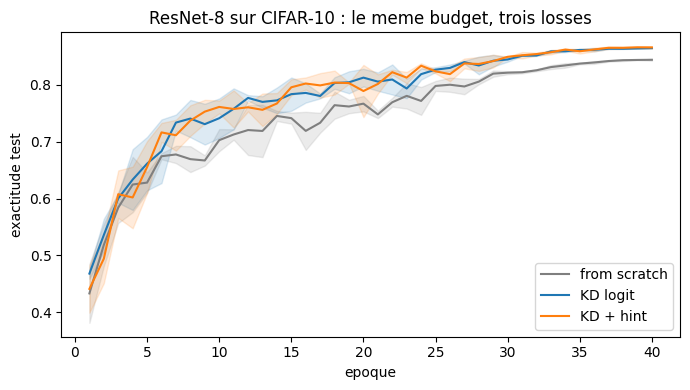

In [10]:
def delta_sigma(a, b):
    d = np.mean(a) - np.mean(b)
    se = np.sqrt(np.std(a) ** 2 + np.std(b) ** 2)
    return d, (d / se if se > 0 else float("nan"))


for name, accs in [("KD logit", accs_kd), ("KD + hint", accs_hint)]:
    d, s = delta_sigma(accs, accs_scratch)
    print(f"{name:10s} vs scratch : {d:+.4f}  ({s:+.1f} sigma)")

import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
for (name, runs), color in zip(
        [("from scratch", runs_scratch), ("KD logit", runs_kd), ("KD + hint", runs_hint)],
        ["tab:gray", "tab:blue", "tab:orange"]):
    h = np.array([r[1] for r in runs])
    plt.plot(range(1, len(h[0]) + 1), h.mean(0), color=color, label=name)
    plt.fill_between(range(1, len(h[0]) + 1), h.mean(0) - h.std(0), h.mean(0) + h.std(0),
                     color=color, alpha=0.15)
plt.xlabel("epoque"); plt.ylabel("exactitude test")
plt.title("ResNet-8 sur CIFAR-10 : le meme budget, trois losses")
plt.legend(); plt.tight_layout(); plt.show()

**Lecture.** À budget d'entraînement identique (40 époques, même recette SGD, mêmes augmentations), la distillation fait gagner **+2,05 points** à l'élève ResNet-8 — un écart de **12,6 σ** au sens des trois graines (0,8437 ± 0,0015 sans maître contre 0,8642 ± 0,0006 avec), bien au-delà du seuil de bruit. C'est le cœur du résultat : le maître ResNet-20 (0,9012, cellule d'entraînement ci-dessus) transfère de la connaissance à un réseau **3,5 fois plus petit** qui n'a jamais vu ses poids. Le paiement est modeste : 567 s par entraînement scratch contre 556 s pour la version distillée (chrono du tableau final) — la passe professeur gelée par lot ne renchérit pas l'entraînement.

La comparaison des écart-types est aussi instructive que les moyennes : ± 0,0006 pour l'élève distillé contre ± 0,0015 pour le scratch. La cible du maître, plus « plate » que les étiquettes one-hot (cf. la démonstration sur la température), régularise l'entraînement et réduit la variance inter-graines.

Le hint FitNets, lui, n'ajoute rien de significatif ici : +0,0012 (0,8654 ± 0,0022) par rapport aux seuls logits, soit ~0,5 σ une fois les erreurs propagées (les +8,1 σ affichés se mesurent contre le scratch, pas contre le KD-logit). La cellule « composantes » l'explique en creux : au premier lot, le signal de hint (rel-MSE = 2,69) est bien actif, mais sur ce couple maître/élève de même famille, les logits portent déjà l'essentiel de l'information — le hint se paierait mieux avec un élève plus profond ou hétérogène (configuration où les features intermédiaires divergent davantage).

## 6. La température — trop bas, un verrou ; trop haut, un brouillard

Le balayage ci-dessous reprend la KD logit sur une seule graine (la comparaison inter-T n'exige pas les trois) pour T ∈ {1, 2, 4, 8}. Ce qu'on cherche : la zone où la dark knowledge est *lisible* — assez tempérée pour que la hiérarchie des classes apparaisse, assez nette pour que l'information subsiste.

In [11]:
sweep = {}
for T in (1.0, 2.0, 4.0, 8.0):
    acc, _, sec = run_student("kd", SEEDS[0], T=T)
    sweep[T] = acc
    print(f"T={T:.0f} : {acc:.4f}  ({sec:.0f}s)")

T=1 : 0.8512  (522s)


T=2 : 0.8624  (537s)


T=4 : 0.8647  (586s)


T=8 : 0.8595  (548s)


**Lecture.** La température n'est pas un réglage gratuit : T=1 (distiller les logits bruts, proches du one-hot) ne récupère qu'un tiers du gain complet (0,8512, soit +0,0075 sur le scratch 0,8437, contre +0,0205 à T=4) ; le sommet se situe vers **T=4** (0,8647) et T=8 redescend (0,8595). Cette courbe en cloche est exactement la prédiction de la démonstration d'ouverture : à basse température, la distribution du maître est trop pointue et n'apporte que la classe dominante ; à haute température, elle devient si plate que la structure fine — les *dark knowledge*, cette masse de 0,609 répartie sur les classes non-cibles — se dilue. La valeur retenue (T=4, α=0,7) est le sommet **mesuré** de cette cloche, pas une convention copiée.

Ces quatre points viennent d'une seule graine (le balayage à 3 graines coûterait ~1 h 15 de GPU supplémentaires) : l'ordre T=4 > T=2 > T=8 > T=1, avec des écarts de 0,2 à 1,4 point, dépasse de loin l'écart-type inter-graines mesuré sur les cellules précédentes (± 0,0006 à ± 0,0022) — la hiérarchie est donc robuste, même si les valeurs exactes bougeraient d'une graine à l'autre.

In [12]:
print(f"{'configuration':26s} {'exactitude':>22s} {'params':>10s} {'temps/run':>10s}")
print(f"{'maitre ResNet-20':26s} {acc_teacher:>22.4f} {n_t:>10,} {'':>10s}")
print(f"{'eleve from scratch':26s} {np.mean(accs_scratch):>13.4f} +/- {np.std(accs_scratch):<7.4f} {n_s:>10,} "
      f"{np.mean([r[2] for r in runs_scratch]):>9.0f}s")
print(f"{'eleve KD logit':26s} {np.mean(accs_kd):>13.4f} +/- {np.std(accs_kd):<7.4f} {n_s:>10,} "
      f"{np.mean([r[2] for r in runs_kd]):>9.0f}s")
print(f"{'eleve KD + hint':26s} {np.mean(accs_hint):>13.4f} +/- {np.std(accs_hint):<7.4f} {n_s:>10,} "
      f"{np.mean([r[2] for r in runs_hint]):>9.0f}s")
print(f"\ncompression : {n_t / n_s:.1f}x moins de poids ; "
      f"ecart eleve(KD)-maitre : {np.mean(accs_kd) - acc_teacher:+.4f}")

configuration                          exactitude     params  temps/run
maitre ResNet-20                           0.9012    272,474           
eleve from scratch                0.8437 +/- 0.0015      78,042       567s
eleve KD logit                    0.8642 +/- 0.0006      78,042       556s
eleve KD + hint                   0.8654 +/- 0.0022      78,042       563s

compression : 3.5x moins de poids ; ecart eleve(KD)-maitre : -0.0370


**Lecture.** Le tableau final résume l'échange : pour **3,5 fois moins de poids** (272 474 → 78 042 paramètres), l'élève distillé rend 0,8642–0,8654 contre 0,9012 au maître — il laisse **3,6 à 3,7 points** sur la table, mais il en gagne **2,0 à 2,2** sur l'entraînement from scratch au même budget, avec un écart-type inter-graines divisé par 2,5. La distillation n'est donc pas une compression gratuite — contrairement à la quantification INT8 du [3.9a](3.9a-Compression-Quantization-INT8.ipynb), qui rend le FP32 à ±0,001 près : c'est un **rattrapage partiel** du maître par un réseau plus petit, au prix d'avoir d'abord entraîné le maître (~9 min de GPU ici). Les deux leviers sont complémentaires — distiller pendant l'entraînement, quantifier au déploiement — et l'exercice 3 vous fait mesurer précisément ce que la température fait à cette connaissance transférée.

## Résumé

- **Loss de distillation** `(1−α)·CE + α·T²·KL(softmax(z_t/T) ‖ softmax(z_s/T))` écrite à la main : la démonstration d'ouverture montre ce que T fait à la distribution du maître — la masse portée par les classes non-cibles passe de 0,086 (T=1) à 0,609 (T=4). C'est cette structure fine, les *dark knowledge*, que l'élève reçoit en plus des étiquettes.
- **Mesure centrale** (CIFAR-10, ResNet-8 de 78 042 paramètres, 3 graines, même recette SGD/cosine/crop+flip) : scratch **0,8437 ± 0,0015** → distillé T=4 α=0,7 **0,8642 ± 0,0006** → + hint FitNets **0,8654 ± 0,0022**. Le gain KD vs scratch vaut **+12,6 σ** ; le hint n'ajoute rien de significatif par rapport aux seuls logits (~0,5 σ) sur ce couple maître/élève.
- **Température** : balayage T ∈ {1, 2, 4, 8} en graine unique — cloche avec sommet mesuré à T=4 (0,8512 / 0,8624 / 0,8647 / 0,8595) ; T=1 ne récupère qu'un tiers du gain.
- **Coût** : ~9 min pour entraîner le maître ResNet-20 (0,9012), puis ~9,5 min par élève ; la version distillée n'est pas plus chère que le scratch (556 s contre 567 s par run).
- **Verdict** : à architecture et budget fixés, la distillation est un rattrapage mesurable et reproductible (12,6 σ, pas un artefact de graine), qui laisse tout de même 3,7 points au maître — le pendant « entraînement » de la compression, là où le 3.9a montrait son pendant « déploiement » quasi gratuit (INT8).

## Exercice 1 — Étiquettes rares : le terrain où la distillation rapporte le plus

Le protocole de ce notebook est volontairement à **budget complet** (50 000 étiquettes, autant d'époques pour tous) : c'est le terrain le plus dur pour la KD, celui où son avantage est le plus petit. [3.7](3.7-Distillation-Maitre-Eleve.ipynb) a montré l'autre terrain : quand les étiquettes deviennent rares, le maître — qui a vu toutes les données — vaut soudain beaucoup plus que les étiquettes disponibles. À votre tour de le mesurer ici : restreindre l'entraînement à 20 % du train set et comparer `scratch` contre `kd` sur ce budget réduit.

**Objectif** : écrire `subset_loader(frac, seed)`, renvoyant un DataLoader d'entraînement sur un `torch.utils.data.Subset` aléatoire seedé de `train_set`. **Question** : l'écart KD vs scratch grandit-il quand les étiquettes se raréfient ?

In [13]:
def subset_loader(frac, seed):
    # TODO etudiant : DataLoader d'entrainement sur une fraction aleatoire seedee
    # de train_set (torch.utils.data.Subset + permutation seedee).
    # Indice : g = torch.Generator().manual_seed(seed) ;
    #          idx = torch.randperm(len(train_set), generator=g)[:int(len(train_set) * frac)]
    # Etape 1 : le Subset des indices tires.
    # Etape 2 : le DataLoader (batch_size=256, shuffle=True).
    return None  # TODO etudiant


l20 = subset_loader(0.2, 0)
if l20 is not None:
    a_scr = run_student("scratch", 0, loader=l20)[0]
    a_kd = run_student("kd", 0, loader=l20)[0]
    print(f"budget 20% des etiquettes : scratch {a_scr:.4f} vs KD {a_kd:.4f}")
    print("  (a comparer avec l'ecart a budget complet : section 4)")
else:
    print("Exercice a completer")

Exercice a completer


## Exercice 2 — Un autre hint : similarité cosinus

Le hint de la section 5 pénalise l'erreur quadratique **relative** entre cartes. La littérature en connaît d'autres ; la plus robuste aux changements d'échelle est la **similarité cosinus** sur les cartes aplaties : on pousse l'élève à *pointer dans la même direction* que le maître, sans contraindre la norme.

**Objectif** : écrire `hint_cosine(h_s, h_t)` renvoyant `1 − moyenne des similarités cosinus` sur les cartes aplaties. **Question** : à β égal, fait-elle mieux que la MSE relative ?

In [14]:
def hint_cosine(h_s, h_t):
    # TODO etudiant : 1 - moyenne de F.cosine_similarity sur les cartes aplaties.
    # Indice : .flatten(1) met les cartes en (B, C*8*8) ; F.cosine_similarity(a, b, dim=1)
    # renvoie un vecteur par image ; la loss est 1 - sa moyenne.
    return None  # TODO etudiant


demo = hint_cosine(torch.randn(8, 32, 8, 8), torch.randn(8, 32, 8, 8))
if demo is not None:
    print(f"sanity : hint_cosine(bruit, bruit) = {demo:.4f}  (attendu ~1 : directions independantes)")
    acc_cos = run_student("kd_hint", SEEDS[0], beta=1.0, hint_fn=hint_cosine)[0]
    print(f"[hint cosinus, beta=1] {acc_cos:.4f}  (a comparer : MSE relative {np.mean(accs_hint):.4f})")
else:
    print("Exercice a completer")

Exercice a completer


## Exercice 3 — Pousser la température trop loin

Le balayage de la section 6 s'arrête à T = 8. Que se passe-t-il à T = 16, quand la distribution du maître devient si plate que la dark knowledge se dilue ? Diagnostic en deux mesures : l'**entropie** de la distribution tempérée (la platitude) et l'exactitude de l'élève.

**Objectif** : écrire `entropie_moyenne(m, T)`, l'entropie moyenne (en bits) de `softmax(logits/T)` sur un lot de test. **Question** : à T = 16, l'entropie approche-t-elle le maximum log₂(10) ≈ 3,32 bits — et l'élève décroche-t-il ?

In [15]:
def entropie_moyenne(m, T, loader=test_loader):
    # TODO etudiant : entropie moyenne (base 2) de softmax(logits/T) sur un lot de test.
    # Indice : p = F.softmax(logits / T, dim=1) ;
    #          H = -(p * p.clamp_min(1e-12).log2()).sum(1) puis moyenne sur le lot.
    # Etape 1 : un lot en mode eval, sans gradient.
    # Etape 2 : renvoyer le H moyen.
    return None  # TODO etudiant


H16 = entropie_moyenne(teacher, 16.0)
if H16 is not None:
    print(f"entropie du maitre a T=16 : {H16:.3f} bits  (max log2(10) = {np.log2(10):.3f})")
    acc16, _, _ = run_student("kd", SEEDS[0], T=16.0)
    print(f"[eleve T=16] {acc16:.4f}  (a comparer au balayage de la section 6)")
else:
    print("Exercice a completer")

Exercice a completer


## Pour aller plus loin

- [3.7 — Distillation maître-élève](3.7-Distillation-Maitre-Eleve.ipynb) : l'ancêtre de ce notebook — KD logit sur MLP/Fashion-MNIST, budget d'étiquettes rares, facteur T² vérifié expérimentalement.
- [3.9a — Quantification INT8](3.9a-Compression-Quantization-INT8.ipynb) : l'autre axe de compression (les nombres) — les deux se combinent (distiller puis quantifier).
- [FT-05 — Model merging & routing](../../../GenAI/FineTuning/FT-05-ModelMerging-Routing.ipynb) : une autre façon de faire coopérer des réseaux entraînés.
- Hinton, Vinyals & Dean, *Distilling the Knowledge in a Neural Network* (2015) ; Romero et al., *FitNets: Hints for Thin Deep Nets* (2015).

**Environnement** : kernel `coursia-ml-training` (torch + torchvision + matplotlib). L'entraînement complet (maître + 12 élèves + balayage de température) prend comptez environ 2 h sur un GPU (RTX 3080 Ti Laptop ici : maître ~9 min, 9 entraînements d'élève ~9,5 min chacun, balayage T 4 × ~9 min) ; sur CPU le notebook s'exécute avec une recette réduite (6 époques, 1 graine).